Quickstart
==========


![](../../plots/general_illustration.png)

HMP is an open-source Python package to analyze neural time-series (e.g. EEG) to estimate Hidden Multivariate Patterns (HMP).  HMP is described in Weindel, van Maanen & Borst (2024, [paper](https://direct.mit.edu/imag/article/doi/10.1162/imag_a_00400/125469/Trial-by-trial-detection-of-cognitive-events-in)
) and is a generalized and simplified version of the HsMM-MVPA method developed by Anderson, Zhang, Borst, & Walsh  ([2016](https://psycnet.apa.org/doi/10.1037/rev0000030)).

As a summary of the method, an HMP model parses the reaction time into a number of successive events determined based on patterns in a neural time-serie. Hence any reaction time can then be described by a number of cognitive events and the duration between them estimated using HMP. The important aspect of HMP is that it is a whole-brain analysis (or whole scalp analysis) that estimates the onset of events on a single-trial basis. These by-trial estimates allow you then to further dig into any aspect you are interested in a signal:
- Describing an experiment or a clinical sample in terms of events detected in the EEG signal
- Describing experimental effects based on the time onset of a particular event
- Estimating the effect of trial-wise manipulations on the identified event presence and time occurrence (e.g. the by-trial variation of stimulus strength or the effect of time-on-task)
- Time-lock EEG signal to the onset of a given event and perform classical ERPs or time-frequency analysis based on the onset of a new event
- And many more (e.g. evidence accumulation models, classification based on the number of events in the signal,...)


## To get started
To get started with the code:
- Check the demo below 
- Inspect the tutorials:
    - [General aspects on HMP (tutorial 1)](notebooks/1-How_HMP_works.ipynb)
    - [The different estimation methods (tutorial 2)](notebooks/2-The_different_model_classes.ipynb)
    - [Applying HMP to real data (tutorial 3)](notebooks/3-Applying_HMP_to_real_data.ipynb)
    - [Load your own EEG data ](notebooks/Data_loading.ipynb)


## Quickstart on simulated data

The following section will quickly walk you through an example usage in simulated data (using [MNE](https://mne.tools/dev/auto_examples/simulation/index.html)'s simulation functions and tutorials)

First we load the packages necessary for the demo on simulated data

### Importing libraries


In [1]:
## Importing these packages is specific for this demo
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gamma

## Importing HMP as you would to analyze data
import hmp
from hmp import simulations #that module is only to simulate things, no need to import when analyzing data


### Simulating data

In the following code block we simulate 200 trials with four HMP events defined as the activation of four neural sources (in the source space of MNE's sample participant). This is not code you would need for your own analysis except if you'd want to simulate and test properties of HMP models. All four sources are defined by a location in sensor space, an activation amplitude and a distribution in time (here a gamma with shape and scale parameters) for the onsets of the events on each trial. The simulation functions are based on this [MNE tutorial ](https://mne.tools/stable/auto_examples/simulation/simulated_raw_data_using_subject_anatomy.html).

> [!NOTE] It can take a while to simulate this data, for faster rendering you can 1) decrease `sfreq` and reduce the number of trials in `n_trials`

In [2]:
n_trials = 200 #Number of trials to simulate, we use 200 to get nice ERPs but you can reduce for speed

##### Here we define the sources of the brain activity (event) for each trial
sfreq = 500#sampling frequency of the signal
n_events = 4 #how many events we want to simulate
frequency = 10.#Frequency of the event defining its duration, half-sine of 10Hz = 50ms
amplitude = .25e-7 #Amplitude of the event in nAm, defining signal to noise ratio
shape = 2 #shape of the gamma distribution
scales = np.array([50, 150, 200, 250, 100])/shape #Mean duration of the time between each event in ms
names = simulations.available_sources()[[22,33,55,44,0]]#Which source to activate for each event (see atlas when calling simulations.available_sources())

sources = []
for source in zip(names, scales):#One source = one frequency/event width, one amplitude and a given by-trial variability distribution
    sources.append([source[0], frequency, amplitude, gamma(shape, scale=source[1])])

# Function used to generate the data
files = simulations.simulate(sources, n_trials, 1, 'dataset_README',  overwrite=False, sfreq=sfreq, seed=1)
eeg_file = [files[0][0]]
event_file = files[0][1]
#load electrode position, specific to the simulations
positions = simulations.positions()

/home/gabriel/ownCloud/projects/RUGUU/hmp/hmp/simulations.py:217: UserWarning: 0_raw.fif exists no new simulation performed
  warn(f"{subj}_raw.fif exists no new simulation performed", UserWarning)


### Creating the event structure and plotting the raw data

To recover the data we need to create the event structure based on the triggers created during simulation. This is the same as analyzing real EEG data and recovering events in the stimulus channel. In our case the value 1 signals the onset of the stimulus and 6 the moment of the response. Hence a trial is defined as the times occuring between the triggers 1 and 6.

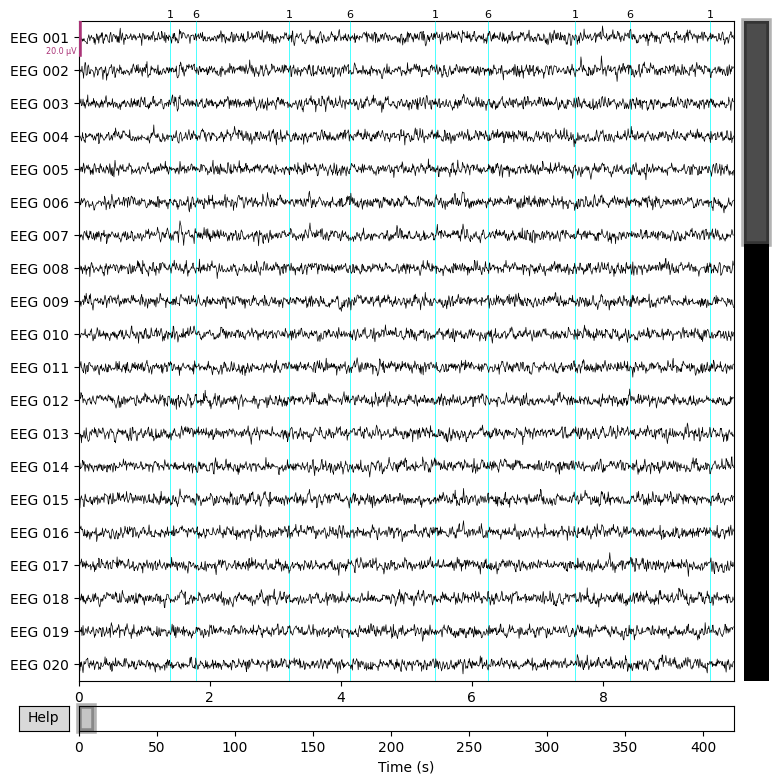

In [3]:
#Recovering the events to epoch the data (in the number of trials defined above)
generating_events = np.load(event_file)
resp_trigger = int(np.max(np.unique(generating_events[:,2])))#Resp trigger is the last source in each trial
event_id = {'stimulus/dummy':1}#trigger 1 = stimulus
resp_id = {'response/dummy':resp_trigger}
#Keeping only stimulus and response triggers
events = generating_events[(generating_events[:,2] == 1) | (generating_events[:,2] == resp_trigger)]#only retain stimulus and response triggers

#Visualising the raw simulated EEG data
import mne

raw = mne.io.read_raw_fif(eeg_file[0], preload=False, verbose=False)
raw.pick_types(eeg=True).plot(scalings=dict(eeg=1e-5), events=events, block=True);

### Recovering number of events as well as actual by-trial variation

To see how well HMP does at recovering by-trial events, first we get the ground truth from our simulation. Unfortunately, with an actual dataset you don’t have access to this, of course. 

In [4]:
#Recover the actual time of the simulated events
sim_event_times = np.reshape(np.ediff1d(generating_events[:,0],to_begin=0)[generating_events[:,2] > 1], \
           (n_trials, n_events+1))
sim_event_times_cs = np.cumsum(sim_event_times, axis=1)

## Demo for a single participant in a single condition based on the simulated data

First we read the EEG data as we would for a single participant

In [5]:
# Info on channel location
montage = simulations.sim_info().get_montage()

# Define some preprocessing arguments
preprocessing = dict(sfreq=sfreq, #Resampling the data at this sampling frequency
                     lowpass=40, # at which frequency we want to apply the lowpass filter
                     highpass=None, #Same for highpass
                     reference='average', #What reference shold the data be re-referenced to
                     pick_channels='eeg' #What channels do we want, can also be a list of channel names
                    )

# Define some epoching arguments
epoching = dict(
    tmin=-.2,# Time to keep before stim onset for baseline correction
    tmax=2#Up to when should we look for a duration end (e.g. response) event
    )

# Reading the data that is in raw .fif format (.bdf also supported by this function)
epoch_data, info = hmp.io.read_mne_raw(eeg_file,
                             centering_id=event_id,
                             event_id=resp_id, 
                             events_provided=[events],#Usually not necessary for real data
                             montage = montage,
                             preprocessing_kwargs=preprocessing,
                             epoching_kwargs=epoching
                            )

Processing dataset dataset_README
Opening raw data file /home/gabriel/ownCloud/projects/RUGUU/hmp/docs/source/dataset_README_raw.fif...
    Read a total of 1 projection items:
        Average EEG reference (1 x 60) active
    Range : 0 ... 209841 =      0.000 ...   419.682 secs
Ready.
Reading 0 ... 209841  =      0.000 ...   419.682 secs...
EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Removing existing average EEG reference projection.
Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 165 samples (0.330 s)

Sampling frequency of the instance is alr

Next we preprocess the data by applying a spatial principal components analysis (PCA) to reduce the dimensionality of the data. 

In this case we choose 5 principal components for commodity and speed.

In [6]:
preprocessed = hmp.basedata.default(epoch_data, n_comp=5, duration_id = 'response_time')

Found 200 trials with positively defined durations and 0 trials without durations (0 or nan)

Rejection summary: 
 0 trials rejected based on threshold of inf 
 0 trials rejected  based on duration limit of (0.002, inf) 
 0 with duration but without data (nan at time 0)


## HMP model

Once the data is in the expected format, we can initialize an HMP object; note that no estimation is performed yet.


In [7]:
model = hmp.models.CumulativeMethod()

### Estimating an HMP model

We can directly fit an HMP model without giving any info on the number of events (see tutorial 2 for a detailed explanation of the following cell:

In [8]:
# Estimate model parameters and transform the data into event probability space
loglikelihood, estimates = model.fit_transform(preprocessed)

  0%|          | 0/29 [00:00<?, ?it/s]

1 events found around times [50]
2 events found around times [48, 216]
3 events found around times [48, 210, 424]
4 events found around times [48, 210, 420, 682]


### Visualizing results of the fit

In the previous cell we initiated an HMP model looking for default 50ms half-sine in the EEG signal. The method discovered four events, and therefore five gamma-distributed time distributions with a fixed shape of 2 and an estimated scale. We can now inspect the results of the fit.

We can directly take a look to the topologies and latencies of the events by calling ```hmp.visu.plot_topo_timecourse```



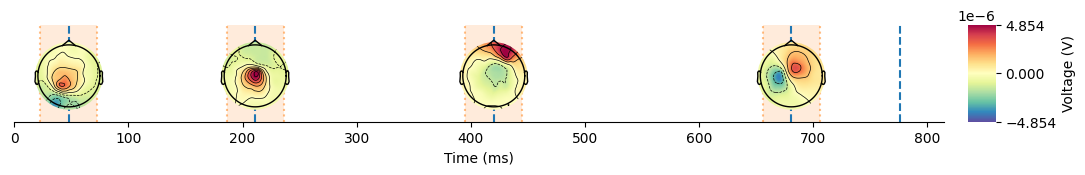

In [9]:
hmp.visu.plot_topo_timecourse(epoch_data, estimates, #Data and estimations
                               positions,#position of the electrodes and initialized model
                               magnify=1, sensors=False)#Display control parameters

This shows us the electrode activity on the scalp as well as the average time of occurrence of the events.

But HMP doesn't provide point estimate but location probability of each of the detected event and that for each trial, example for the last simulated trial

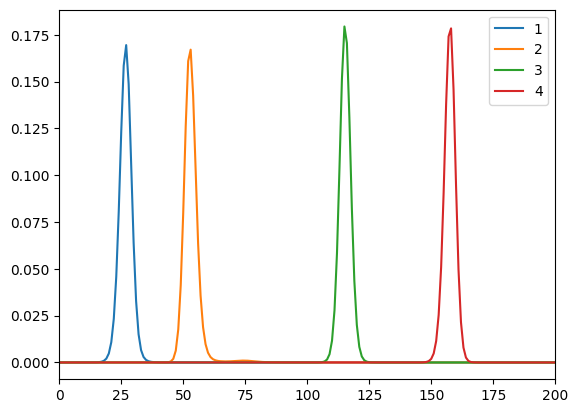

In [10]:
plt.plot(estimates.isel(trial=-1), label=[1,2,3,4])
plt.xlim(0,200)
plt.legend()


This then shows the likeliest event onset location in time for the last simulated trial!

### Comparing with ground truth

As we simulated the data we have access to the ground truth of the underlying generative events. We can then compare the generated single trial peaks for each event with those estimated from the HMP model

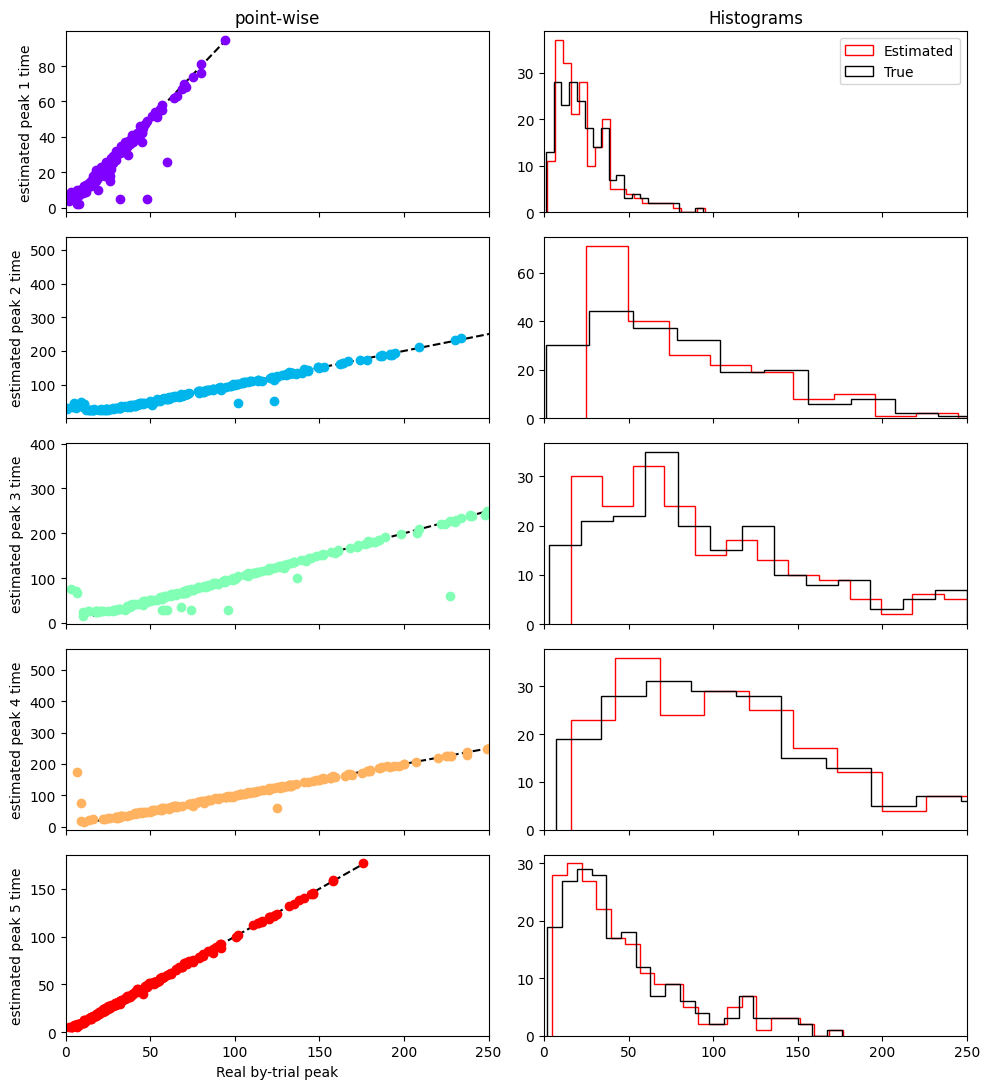

In [11]:
estimated_times = hmp.utils.event_times(estimates, duration=True, mean=False, add_rt=True).T
colors = plt.cm.rainbow(np.linspace(0, 1, 5))
fig, ax = plt.subplots(n_events+1,2, figsize=(10,2.5*n_events+1), dpi=100, sharex=True)
i = 0
ax[0,0].set_title('point-wise')
ax[0,1].set_title('Histograms')
ax[-1,0].set_xlabel('Real by-trial peak')

for event in estimated_times:
    ax[i,0].plot([np.min(event), np.max(event)], [np.min(event), np.max(event)],'--', color='k')

    ax[i,0].plot(sim_event_times[:,i], event, 'o', color=colors[i])
    ax[i,0].set_ylabel(f'estimated peak {i+1} time')
    ax[i,1].hist(event, color='red', bins=20, histtype='step', label='Estimated')
    ax[i,1].hist(sim_event_times[:,i].T, color='k', bins=20, histtype='step', label='True')
    i+= 1
ax[0,-1].legend()
plt.xlim(0,250)
plt.tight_layout();


We see that every events gets nicely recovered even on a by-trial basis!


## We have by-trial estimates. Now what?

HMP just helped us estimate at which time point single-trial events occured. There are plenty of things to do with this information.

As an example consider how average curve of traditional event related potentials (ERP) in EEG are a bad representation of the underlying single-trial event. In the following cell we do the average ERP electrode activity for 4 subselected electrodes in the classical way (stimulus centered)

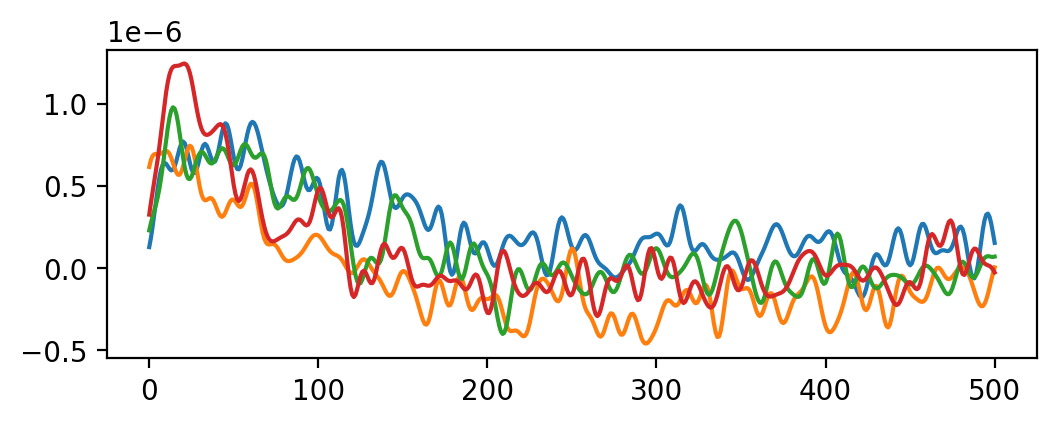

In [12]:
fig, ax = plt.subplots(1,1, figsize=(6,2), sharey=True, sharex=True, dpi=200)
colors = iter([plt.cm.tab10(i) for i in range(10)])

#Cherry picked electrodes
channels = ['EEG 031', 'EEG 039', 'EEG 040', 'EEG 048']
#HMP times
times = hmp.utils.event_times(estimates, mean=False, add_rt=True, add_stim=True)

centered_onstim = hmp.utils.centered_activity(epoch_data,
                times, channels, event=0, n_samples=500)

for channel in channels:
    c = next(colors)
    plt.plot(centered_onstim.sel(channel=channel).data.mean('trial'))

Note that the signal overall doesn't look like the half-sine pattern we simulated. This is because the by-trial time-jitter makes the average ERP **when centered on stimulus** smeared out.

If however we were to average the signal but centered on the single-trial times detected by HMP the picture is this one:

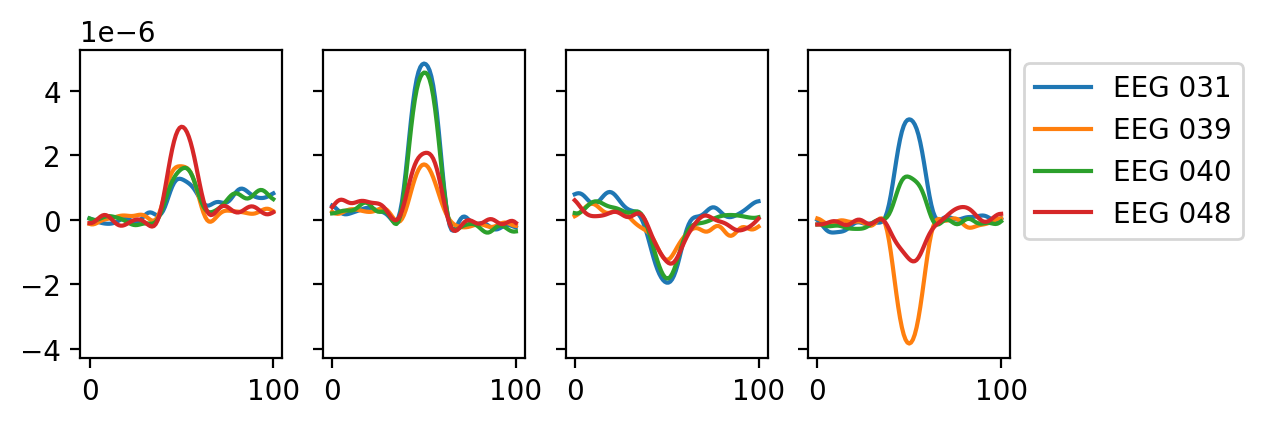

In [13]:
fig, ax = plt.subplots(1,n_events, figsize=(6,2), sharey=True, sharex=True, dpi=200)

#Cherry picked electrodes
channels = ['EEG 031', 'EEG 039', 'EEG 040', 'EEG 048']
#HMP times
times = hmp.utils.event_times(estimates, mean=False, add_rt=True, add_stim=True)

for event in range(n_events):
    centered_onev = hmp.utils.centered_activity(epoch_data,
                times, channels, event=event+1, n_samples=50, baseline=-50)
    colors = iter([plt.cm.tab10(i) for i in range(10)])
    for channel in channels:
        c = next(colors)
        ax[event].plot(centered_onev.sel(channel=channel).data.mean('trial'), label=channel)
ax[-1].legend(bbox_to_anchor=(1,1));

Compared to the traditional ERP representation we see that HMP provides a much better view of the underlying single-trial activities than the tradition ERP (remember we simualted half-sines).

Now HMP is not merely a method to look at ERPs or by-trial times. A lot can be done once the estimation has been made, for example:
- Connectivity analysis starting from each event onset
- Time/frequency decomposition
- Single-trial signal analysis with, e.g. a single-trial covariate
- and so on 

### Follow-up

For examples on how to use the package on real data, or to compare event time onset across conditions see the tutorial notebooks:
- [General aspects on HMP (tutorial 1)](notebooks/1-How_HMP_works.ipynb)
- [The different estimation methods (tutorial 2)](notebooks/2-The_different_model_classes.ipynb)
- [Applying HMP to real data (tutorial 3)](notebooks/3-Applying_HMP_to_real_data.ipynb)
- [Load your own EEG data ](notebooks/Data_loading.ipynb)